In [2]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc3 as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [3]:
def vonmises_pdf(x, mu, kappa):
    return np.exp(kappa * np.cos(x - mu)) / (2 * np.pi * i0(kappa))

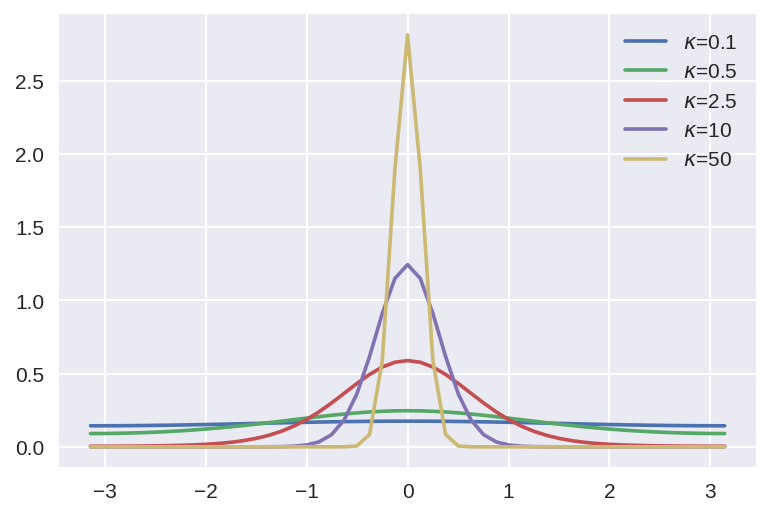

In [3]:
x = np.linspace(-np.pi, np.pi, num=51)
kappas = [0.1, 0.5, 2.5, 10, 50]
ys = np.array([vonmises_pdf(x, 0, kappa) for kappa in kappas])
fig, ax = plt.subplots(dpi=150)
for y, kappa in zip(ys, kappas):
    ax.plot(x, y, label=f"$\kappa$={kappa}")
    ax.legend()

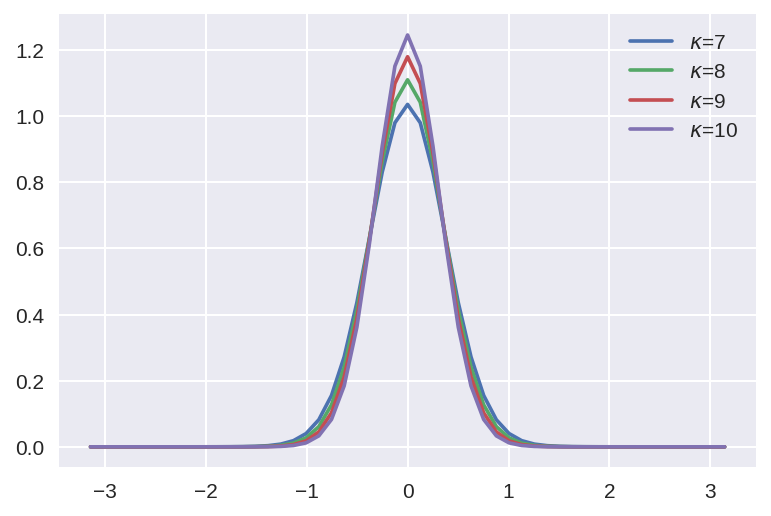

In [9]:
x = np.linspace(-np.pi, np.pi, num=51)
kappas = [7, 8, 9, 10]
ys = np.array([vonmises_pdf(x, 0, kappa) for kappa in kappas])
fig, ax = plt.subplots(dpi=150)
for y, kappa in zip(ys, kappas):
    ax.plot(x, y, label=f"$\kappa$={kappa}")
    ax.legend()

In [4]:
mu, kappa = 0.0, 1
global_orientation = D.Uniform(0, np.pi).sample()
neuronal_filters = np.linspace(0, np.pi, num=8, endpoint=False)

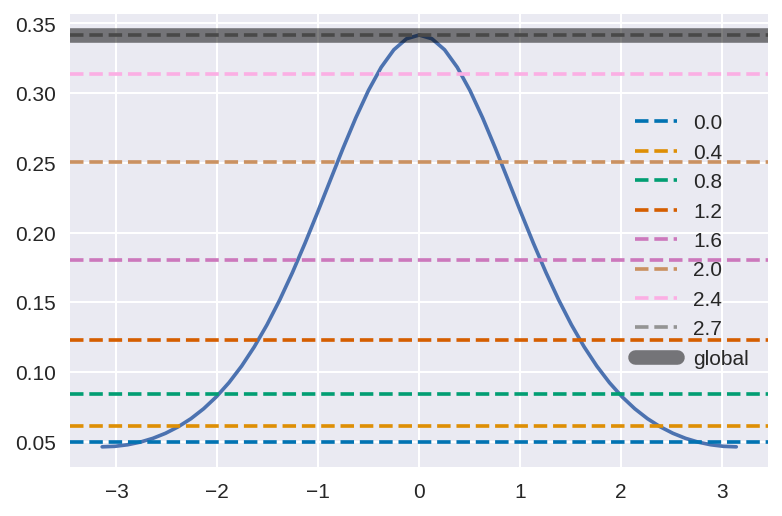

In [5]:
y = vonmises_pdf(x, mu, kappa)
fig, ax = plt.subplots(dpi=150)
ax.plot(x, y)
colors = sns.color_palette("colorblind", n_colors=8)
for neuronal_filter, color in zip(neuronal_filters, colors):
    ax.axhline(
        vonmises_pdf(global_orientation - neuronal_filter, mu, kappa),
        color=color,
        linestyle="--",
        label=f"{neuronal_filter:0.1f}",
    )
    ax.legend()
ax.axhline(
    vonmises_pdf(global_orientation - global_orientation, mu, kappa),
    linewidth=7,
    color="black",
    alpha=0.5,
    label="global",
)
ax.legend()

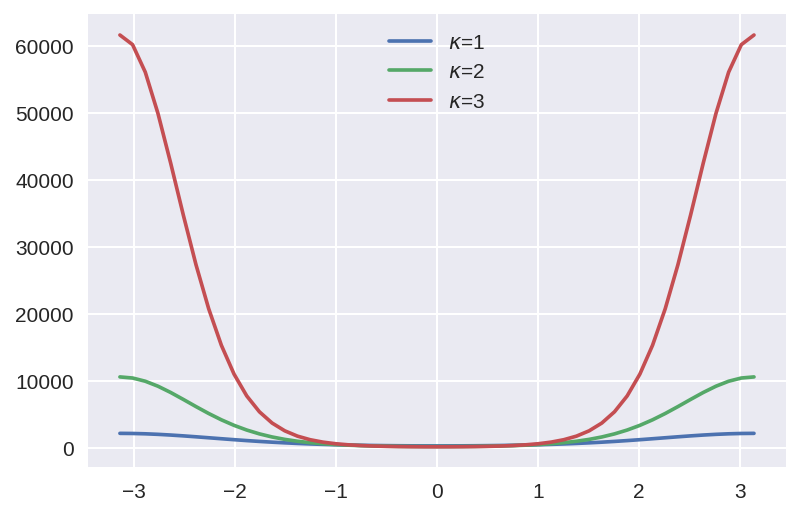

In [11]:
x = np.linspace(-np.pi, np.pi, num=51)
kappas = [1, 2, 3]
ys = np.array([100 / vonmises_pdf(x, 0, kappa) for kappa in kappas])
fig, ax = plt.subplots(dpi=150)
for y, kappa in zip(ys, kappas):
    ax.plot(x, y, label=f"$\kappa$={kappa}")
    ax.legend()